In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import minimize_scalar
# --- 1. Load and Clean Data (Once) ---
df = pd.read_csv("mako_growth_data_by_region.csv", comment="#")

# Filter dataset
df = df[
    (df["age_years"] <= 30) &          
    (df["age_years"].notna()) &        
    (df["mass_kg"].notna()) &          
    (df["mass_kg"] > 0)                
].reset_index(drop=True)

#  Pratt & Casey (1983) and Kohler et al. (1995)
k_vb = 0.12
L_inf = 253.3  # cm
a = 5.243e-6
b = 3.1407

# Calculate constants
w_inf = a * (L_inf ** b)
kappa = 3 * k_vb
eta = kappa * (w_inf ** (1/3))
T_ref = 19.0  # Baseline  Temperature
print(kappa)
print(eta)

# --- Thermal Groups  ---
thermal_groups = {
    "Cold_Temp": ["Pacific_Chile", "Pacific_New_Zealand"],
    "Cool_Temp": ["Pacific_California", "Western_NA"],
    "Warm_Temp": ["Pacific_Australia", "Southwest_SA"],
    "Subtropical": ["Pacific_Baja", "Western_and_Central_NP"],
    "Tropical": ["China", "West_and_Central_SA"]
}
# the temperatures for each zone
zone_temps = {
    "Cold_Temp": 15.0, 
    "Cool_Temp": 17.0,
    "Warm_Temp": 19.0,
    "Subtropical": 21.0,
    "Tropical": 23.0
}

0.36
2.053658057803766


In [2]:
# --- 3. Functions ---

# just the normal euler method with the variables from cell 1 if not overwritten
def simulate_growth(q10, temp, eta_in=None, T_ref_in=None):
    
    #we defined global variables use those, if no new variables are needed
    use_eta = eta if eta_in is None else eta_in
    use_T_ref = T_ref if T_ref_in is None else T_ref_in
    
    t_max = 30
    dt = 0.1
    steps = int(t_max / dt)
    
    
    t_list = []
    m_list = []
    
    m = 3.0 # the mass of the mako shark hen born
    t = 0
    
    # Calculate the temperature factor
    factor = q10 ** ((temp - use_T_ref) / 10.0)
    
    # Loop for Euler method
    for i in range(steps + 1):
        t_list.append(t)
        m_list.append(m)
        
        # the change in mass
        dmdt = factor * (use_eta * m**(2/3) - kappa * m)
        
        m = m + dmdt * dt
        t = t + dt
        
    return np.array(t_list), np.array(m_list) # we return an array of time and mass

# Function to calculate error (MSE) for optimization
# we need this function for multiple other functions so we write it once so we can reuse it multiple times
def calculate_mse(params, data_source=None, eta_in=None, T_ref_in=None):
    q10_val = params
    errors = []
    
    # same thing use normal df if not overwritten by a function
    target_df = df if data_source is None else data_source
    
    for zone, regions in thermal_groups.items():
        temp = zone_temps[zone]
        
        # Get data for this zone
        sub_df = target_df[target_df["region"].isin(regions)]
        
        if len(sub_df) < 5: 
            continue
            
        #here we reuse the function above
        t_pred, m_pred = simulate_growth(q10_val, temp, eta_in, T_ref_in)
        
        # Interpolate predictions because we dont have a mass for every time
        predictions = np.interp(sub_df["age_years"], t_pred, m_pred)
        
        # Calculate MSE
        diff = sub_df["mass_kg"] - predictions
        mse = np.mean(diff**2)
        errors.append(mse)
        
    return np.mean(errors) if errors else 1e6

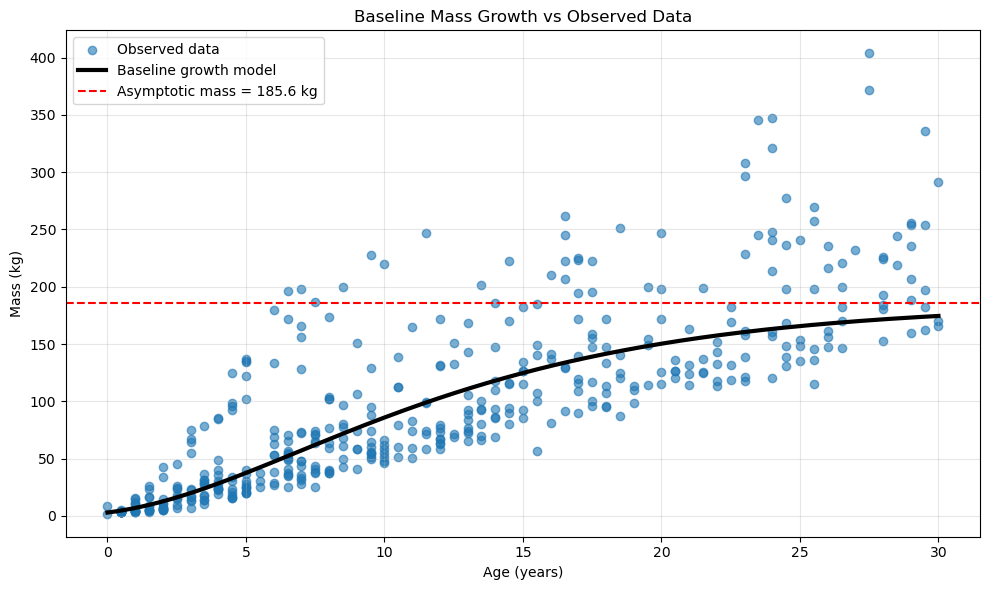

In [3]:
# --- Baseline Growth Model (No Temperature Effects) ---

# Run simulation using q10=1.0 and T_ref (factor becomes 1)
t_arr, M_arr = simulate_growth(q10=1.0, temp=T_ref)

# here we just plot our base model against all our datapoints
plt.figure(figsize=(10, 6))
plt.scatter(df["age_years"], df["mass_kg"], alpha=0.6, label="Observed data")
plt.plot(t_arr, M_arr, linewidth=3, color='k', label="Baseline growth model")
plt.axhline(y=w_inf, linestyle="--", color='r', label=f"Asymptotic mass = {w_inf:.1f} kg")

plt.xlabel("Age (years)")
plt.ylabel("Mass (kg)")
plt.title("Baseline Mass Growth vs Observed Data")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Starting optimization...
Optimization done.
Best Q10: 1.5310991364428306
Final Error: 2651.109854072617


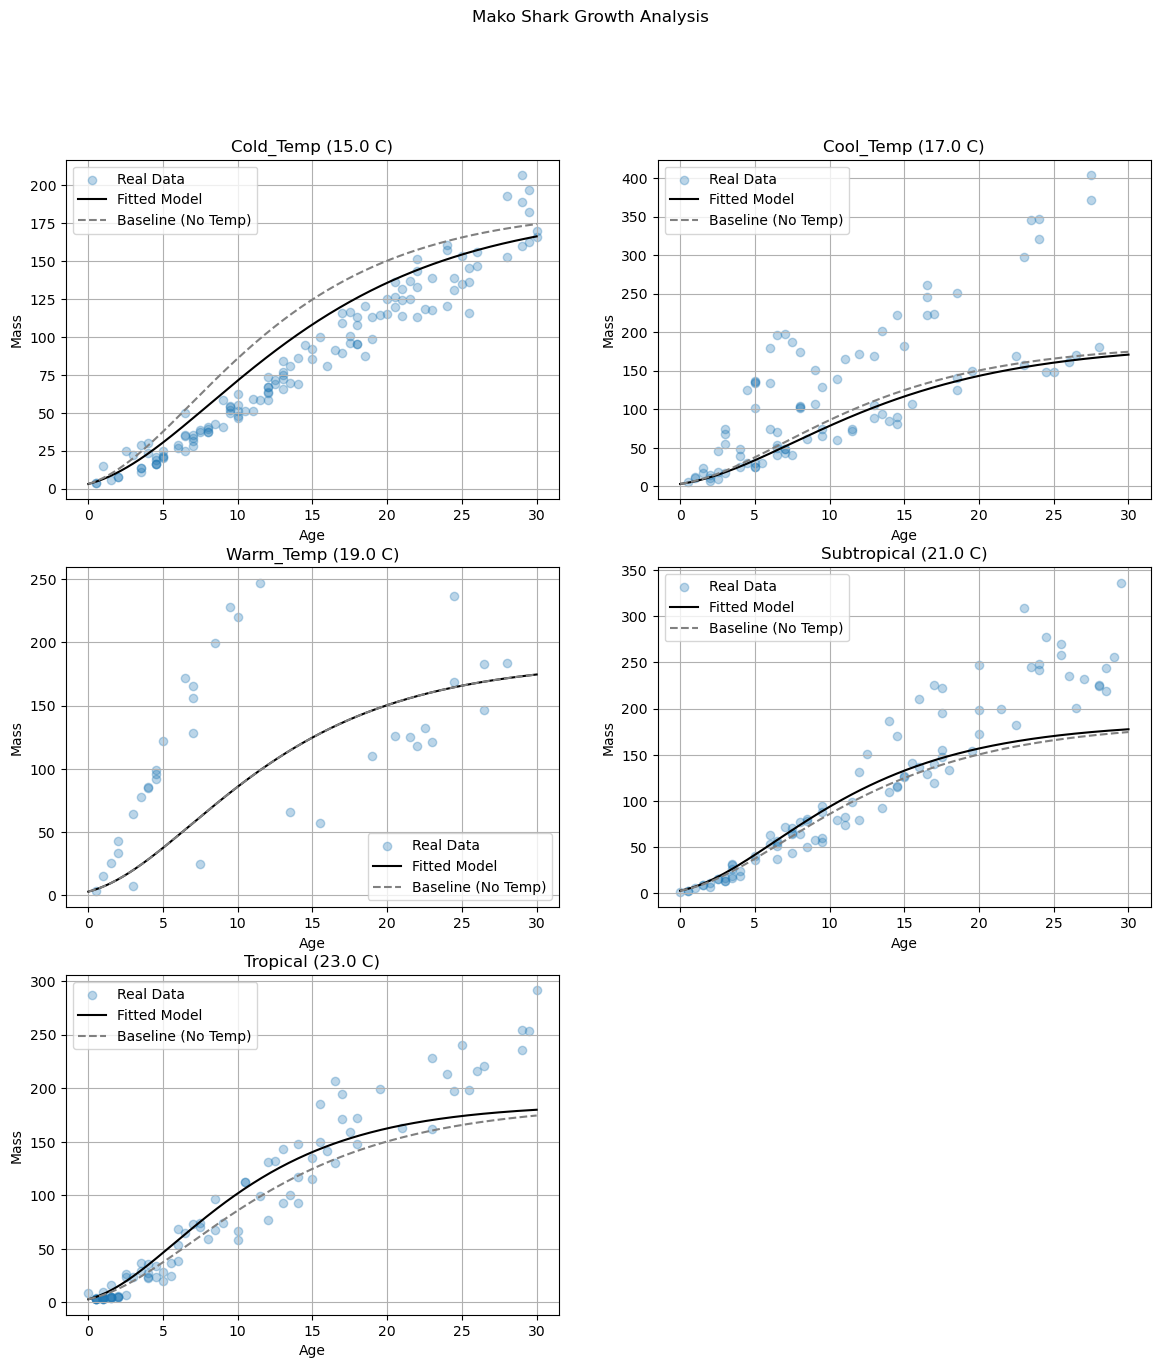

In [4]:
# --- 4. Optimization ---
print("Starting optimization...")


# We reuse the calculate_mse function we defined earlier
result = minimize_scalar(calculate_mse, bounds=(0.1, 4.0), method='bounded') 

best_q10 = result.x
print("Optimization done.")
print("Best Q10:", best_q10)
print("Final Error:", result.fun)

# 5. Plotting
plt.figure(figsize=(14, 15))
count = 1

for zone in thermal_groups:
    plt.subplot(3, 2, count)
    regions = thermal_groups[zone]
    temp = zone_temps[zone]
    
    sub_df = df[df["region"].isin(regions)]
    
    # Simulate with best Q10 using the euler method we defined before
    t_sim, m_sim = simulate_growth(best_q10, temp)
    
    # Simulate with Q10 = 1 so our base model without temperature effects
    t_base, m_base = simulate_growth(1.0, temp)
    
    plt.scatter(sub_df["age_years"], sub_df["mass_kg"], alpha=0.3, label="Real Data")
    plt.plot(t_sim, m_sim, color='black', label="Fitted Model")
    plt.plot(t_base, m_base, color='gray', linestyle='--', label="Baseline (No Temp)")
    
    plt.title(zone + " (" + str(temp) + " C)")
    plt.xlabel("Age")
    plt.ylabel("Mass")
    plt.legend()
    plt.grid(True)
    count += 1

plt.suptitle("Mako Shark Growth Analysis")
plt.savefig("mako_growth_plot.png", dpi=300, bbox_inches='tight')
plt.show()

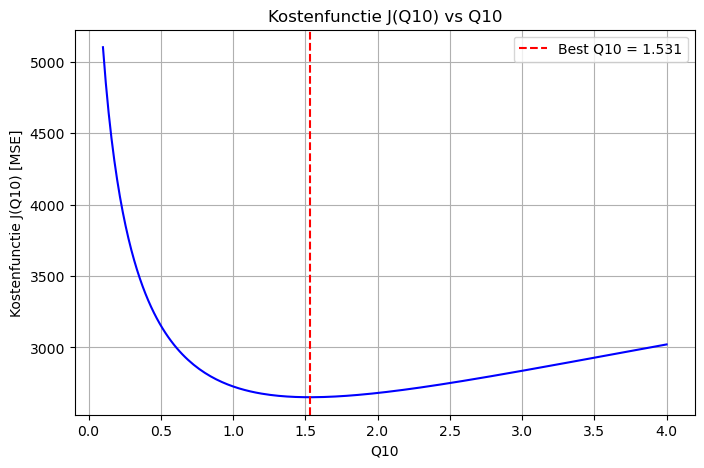

In [5]:
q10_values = np.linspace(0.1, 4.0, 200)
mse_values = [calculate_mse(q) for q in q10_values]

# Plotting
plt.figure(figsize=(8,5))
plt.plot(q10_values, mse_values, color='blue')
plt.axvline(best_q10, color='red', linestyle='--', label=f'Best Q10 = {best_q10:.3f}')
plt.xlabel('Q10')
plt.ylabel('Kostenfunctie J(Q10) [MSE]')
plt.title('Kostenfunctie J(Q10) vs Q10')
plt.legend()
plt.grid(True)
plt.show()

Running 1000 bootstrap iterations...

--- Bootstrap Results ---
Mean Q10: 1.535
95% CI: [1.355, 1.725]


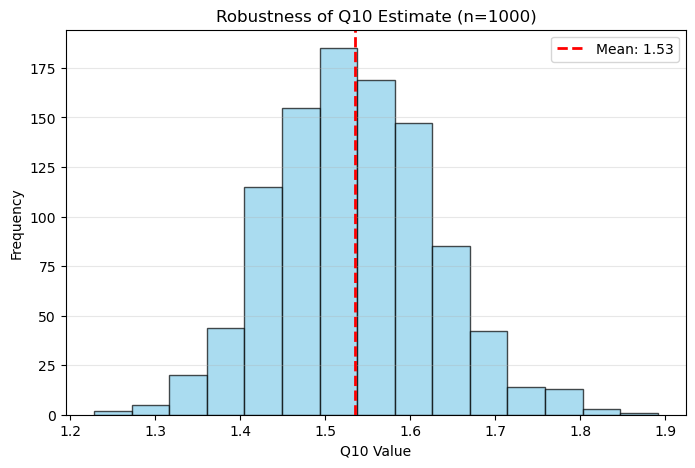

In [6]:
# Bootstrap Analysis 

def bootstrap_q10(n_iterations=1000):
    bootstrapped_q10s = []
    print(f"Running {n_iterations} bootstrap iterations...")
    
    for i in range(n_iterations):
        # Resample data with replacement
        df_resampled = df.sample(n=len(df), replace=True)
        
        # Use centralized error function, passing the resampled dataframe
        #the 1.5 is our initial guess and the minimmize function that we imported does all the work :)
        res = minimize_scalar(calculate_mse, args=(df_resampled), bounds=(0.1, 4.0), method='bounded')
        
        if res.success: bootstrapped_q10s.append(res.x)
            
    return np.array(bootstrapped_q10s)
# we use 1000 iterations
q10_distribution = bootstrap_q10(n_iterations=1000) # so we resample the data 1000 times and calculate Q10 value for each iteration
mean_q10 = np.mean(q10_distribution)
ci_lower = np.percentile(q10_distribution, 2.5) # and then we build the confidence interval(95% percent in our case)
ci_upper = np.percentile(q10_distribution, 97.5)

print(f"\n--- Bootstrap Results ---")
print(f"Mean Q10: {mean_q10:.3f}")
print(f"95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")
#plotting
plt.figure(figsize=(8, 5))
plt.hist(q10_distribution, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(mean_q10, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_q10:.2f}')
plt.title(f"Robustness of Q10 Estimate (n=1000)")
plt.xlabel("Q10 Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

--- Sensitivity Analysis Results ---
Baseline: Q10 = 1.531
L_inf + 10%: Q10 = 1.667
L_inf - 10%: Q10 = 1.399
T_ref = 17°C: Q10 = 1.882
T_ref = 21°C: Q10 = 0.989


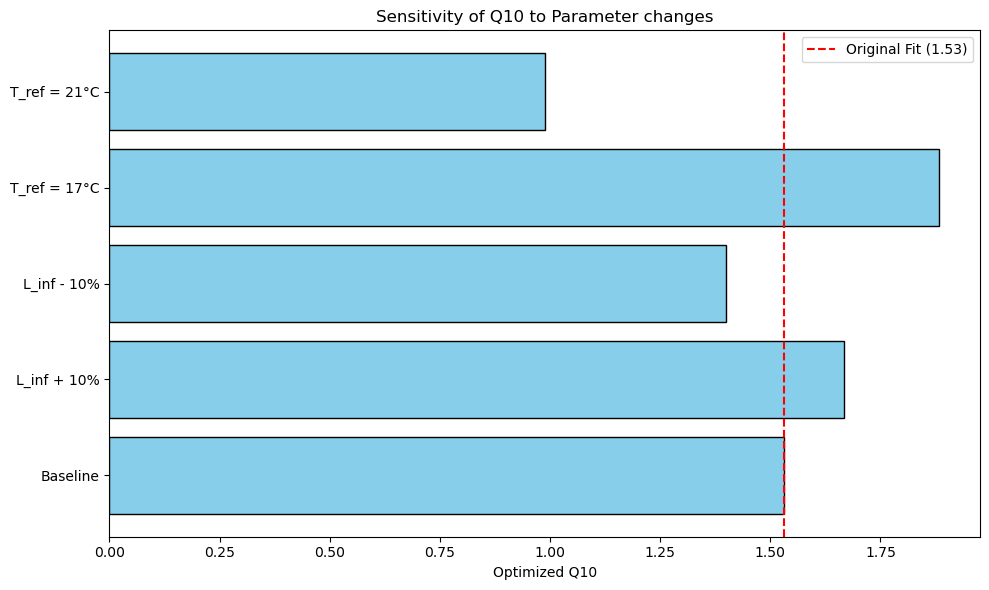

In [7]:
# --- Sensitivity Analysis ---

def run_optimization_variable(l_inf_factor=1.0, t_ref_custom=19.0):
    # Recalculate biological constants based on L_inf factor
    local_L_inf = L_inf * l_inf_factor
    local_w_inf = a * (local_L_inf ** b)
    local_eta = kappa * (local_w_inf ** (1/3))
    

    res = minimize_scalar(calculate_mse, args=(None, local_eta, t_ref_custom), bounds=(0.1, 4.0), method='bounded')
    
    return res.x
#here are all our scenarios we will test for the sensitivity analysis
scenarios = [
    ("Baseline", 1.0, 19.0),
    ("L_inf + 10%", 1.1, 19.0),
    ("L_inf - 10%", 0.9, 19.0),
    ("T_ref = 17°C", 1.0, 17.0),
    ("T_ref = 21°C", 1.0, 21.0)
]
#print the results
print("--- Sensitivity Analysis Results ---")
sens_names = []
sens_values = []

for name, l_fac, tr in scenarios:
    val = run_optimization_variable(l_fac, tr)
    sens_names.append(name)
    sens_values.append(val)
    print(f"{name}: Q10 = {val:.3f}")

plt.figure(figsize=(10, 6))
plt.barh(sens_names, sens_values, color='skyblue', edgecolor='black')
plt.axvline(best_q10, color='red', linestyle='--', label=f'Original Fit ({best_q10:.2f})')
plt.xlabel('Optimized Q10')
plt.title('Sensitivity of Q10 to Parameter changes')
plt.legend()
plt.tight_layout()
plt.show()

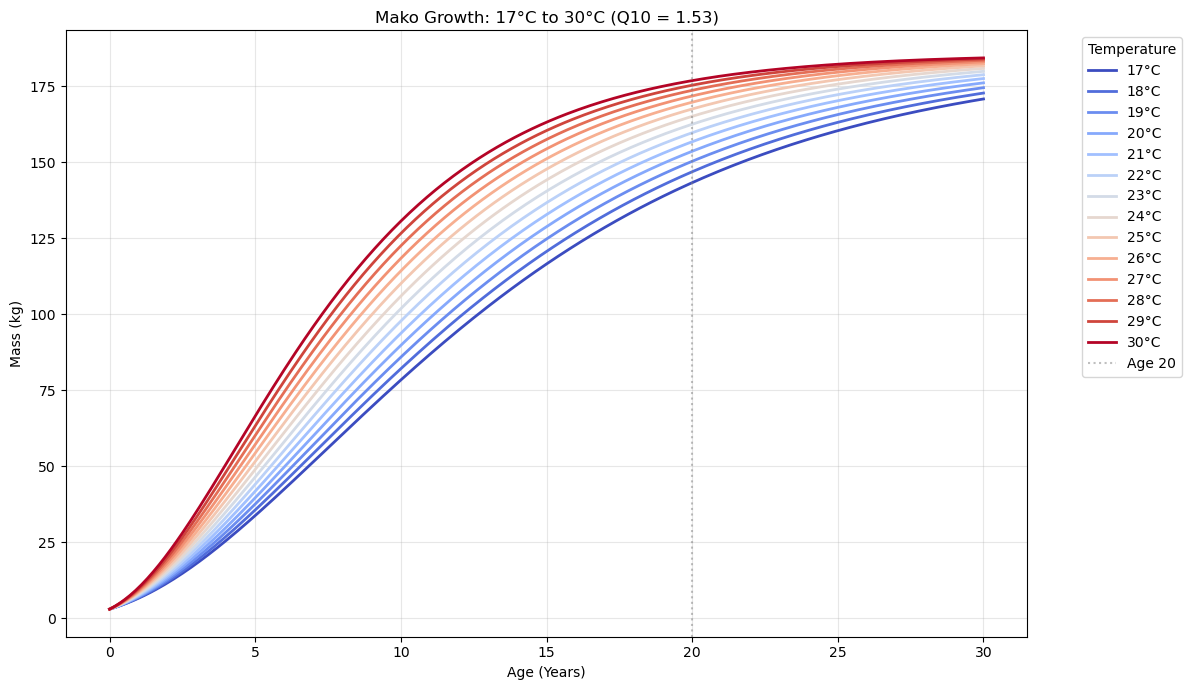

In [8]:

# 1. Define the range of temperatures (17 to 30)
temps = np.arange(17, 31, 1) # Creates an array: [17, 18, ... 30]

# 2. Setup the plot
plt.figure(figsize=(12, 7))

# Generate a list of colors from blue to red
colors = cm.coolwarm(np.linspace(0, 1, len(temps)))

# 3. Loop through each temperature to simulate and plot
for i, current_temp in enumerate(temps):
    # use are growth function again with q10 = 1.53
    t_sim, m_sim = simulate_growth(best_q10, current_temp)
    
    # Plot the line with the specific color
    plt.plot(t_sim, m_sim, color=colors[i], lw=2, label=f"{current_temp}°C")

# 4. Final Plot Formatting
plt.title(f"Mako Growth: 17°C to 30°C (Q10 = {best_q10:.2f})")
plt.xlabel("Age (Years)")
plt.ylabel("Mass (kg)")

# Add a vertical line at Age 20 so we can compare masses
plt.axvline(20, color="gray", alpha=0.5, linestyle=":", label="Age 20")

# Place legend outside the plot 
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Temperature")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()